In [71]:
from msisim.tissue_model import Tissue, Grid
from msisim.composition import Composition, types_stripes, types_random_field, types_checkerboard
from msisim.image_formation import GaussianBeam, RasterScan, k_for_consumption, simulate_raster, scan_extent, detect

import matplotlib.pyplot as plt
import numpy as np

## Simulating different tissue types

We begin by setting up a tissue grid. Spatial units are in microns. Time is in seconds. Our tissue grid will be 200/200 microns, with an average cell diamater of about 25 microns.

<Axes: xlabel='$x$ ($\\mu$m)', ylabel='$y$ ($\\mu$m)'>

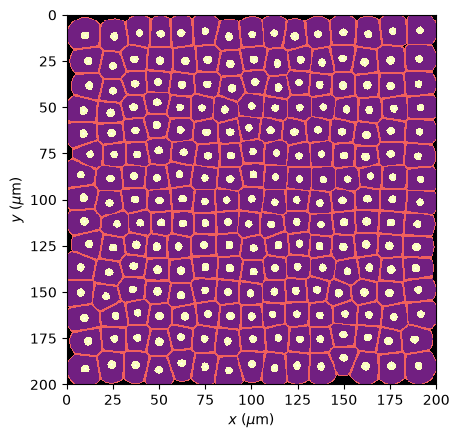

In [17]:
grid = Grid.from_extent(width_um=200, height_um=200, dx=0.5) #dx should be much smaller than beam sigma
tissue = Tissue.jittered_lattice(grid, cell_diam=(12.5, 12.5), jitter=0.12, lloyd_iters=2, seed=16)
tissue.show()


## Chemical/molecular composition 

Next, we we have to define a molecular composition over the tissue grid. So far I have implemented 3 different geometries - stripes, checkerboard and a random field (where we can define proportions of different types, i.e. tumour/stroma regions, etc).

## `Composition` Class
Maps biological cell types and sub-cellular compartments to specific molecular densities.

*   **`species`**: Names of the target molecules (e.g., lipids, metabolites).
*   **`type_means`**: The base abundance of each species per cell type. (Shape: `[Species, CellTypes]`)
*   **`compartment_weights`**: Multipliers defining where molecules localize within a cell (Cytoplasm, Membrane, Nucleus).
*   **`cell_cv`**: Log-normal biological variation between individual cells of the exact same type.
*   **`background`**: Baseline ambient signal in empty, off-tissue regions.


## Random field
types_random_field parameters:

- correlation_um 

    - This controls the physical size of the contiguous cell-type domains in micrometers (the "blob" size). It defines the radius of the Gaussian smoothing applied to the random noise.
    - Use 10 to 30 (roughly 1–3 cell diameters) for highly mixed, heterogeneous tissue where different cell types are thoroughly interspersed (e.g., immune cell infiltration).
    - Use 100 to 300 to simulate distinct macroscopic tissue structures, such as a large solid tumor mass alongside a continuous stroma region. The larger the number, the smoother and more expansive the continuous regions of a single cell type will be.

- proportions 
    - A list defining the relative abundance of each cell type. The length of this list dictates the total number of cell types generated, mapping directly to the type_means array dimensions in your Composition class.
    - Use [0.5, 0.5] for a roughly equal 50/50 split of two cell types.
    - Use [0.8, 0.15, 0.05] for a three-type system where Type 0 dominates the tissue (80%), Type 1 is a margin/minority (15%), and Type 2 is rare (5%).
    - Note: The numbers do not strictly need to sum to 1.0 because the function normalizes them under the hood via p.sum(). Passing [80, 15, 5] yields the exact same result.


## Stripes
Assigns cell types in alternating parallel bands. This is useful for simulating layered structures like the cerebral cortex or skin.

*   **`period_um`**: The physical width (in micrometers) of one full repeating cycle of stripes.
*   **`n_types`**: How many different cell types to cycle through.
*   **`axis`**: Set to `'x'` for vertical stripes or `'y'` for horizontal stripes.


## Checkerboard
Assigns cell types in a rigid grid pattern. This non-biological layout is primarily used for technical validation, testing spatial resolution, and calibrating beam overlap.

*   **`period_um`**: The physical width and height of each individual square block in the grid.
*   **`n_types`**: The number of alternating cell types to cycle through the grid layout.



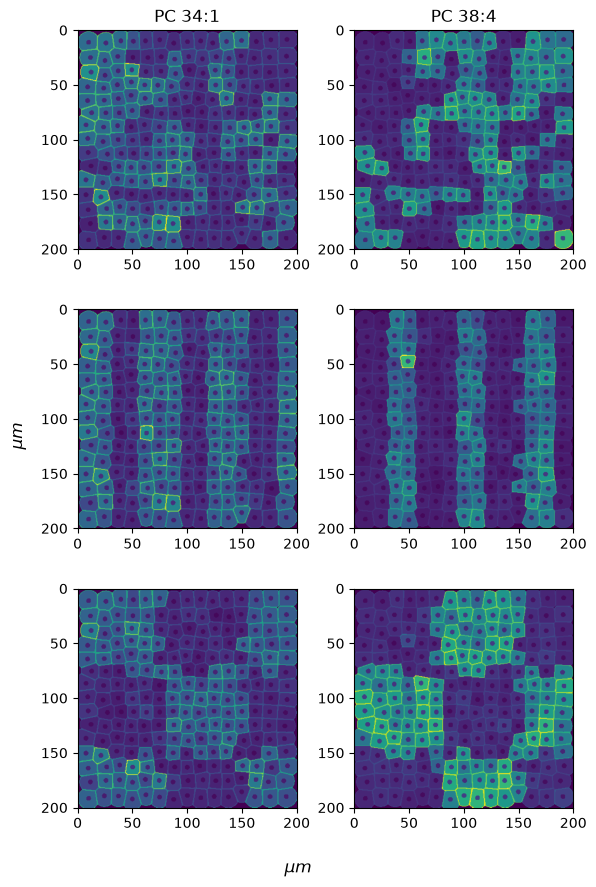

In [61]:

comp = Composition(

    species=["PC 34:1", "PC 38:4"], #random names so far, no mz mappings yet
    type_means= [
                [1.0, 0.4],        # species 0 in type 0, type 1
                [0.2, 0.8]],       # species 1

    compartment_weights=[[1.0, 2.0, 0.3], [1.0, 1.5, 0.3]],
    cell_cv=0.2,
)



random_field = types_random_field(tissue=tissue, correlation_um=10, proportions=[0.5, 0.5],)
stripes = types_stripes(tissue=tissue, period_um=30, n_types=2)
checker = types_checkerboard(tissue=tissue, period_um=75, n_types=2)



rho_random = comp.render(tissue=tissue, cell_types=random_field, seed=1)
rho_stripes = comp.render(tissue=tissue, cell_types=stripes, seed=1)
rho_checker = comp.render(tissue=tissue, cell_types=checker, seed=1)


fig, axs = plt.subplots(3,2, figsize=(6,9))

axs[0,0].imshow(rho_random[0], extent=grid.extent)
axs[0,0].set_title("PC 34:1")
axs[0,1].imshow(rho_random[1], extent=grid.extent)
axs[0,1].set_title("PC 38:4")


axs[1,0].imshow(rho_stripes[0], extent=grid.extent)
axs[1,1].imshow(rho_stripes[1], extent=grid.extent)

axs[2,0].imshow(rho_checker[0], extent=grid.extent)
axs[2,1].imshow(rho_checker[1], extent=grid.extent)

fig.supxlabel("$\\mu m$")
fig.supylabel("$\\mu m$")

plt.tight_layout()
# plt.subplots_adjust(wspace=0.3, hspace=0.005) 


## Image formation model

## `GaussianBeam` Class
Defines the spatial profile and power of the desorption beam (e.g., a laser). 
*   **`sigma_x`, `sigma_y`**: The standard deviation of the beam's Gaussian profile in micrometers ($\mu$m). 
*   **`I0`**: The *total* beam power. 
*   **`.fwhm()`**: Calculates the Full Width at Half Maximum, which is the practical "spot size" of the beam (typically ~$2.355 \times \sigma$).

---

## `RasterScan` Class
Defines the physical path and timing of the mass spectrometer's stage as it scans the tissue.
*   **`x_start`, `y_start`**: The physical starting coordinates (in $\mu$m) of the scan.
*   **`n_pix`, `n_lines`**: The dimensions of the resulting image (spectra per line, and total number of lines).
*   **`pixel_x`**: The horizontal sampling interval. Equal to `velocity` $\times$ `t_sampling`.
*   **`pixel_y`**: The vertical distance between adjacent lines (line pitch).
*   **`velocity`**: Speed of the stage movement in $\mu$m/s.
*   **`duty_cycle`**: The fraction of the sampling interval where the detector is actively recording.

---

## Physics & Consumption Functions
Controls how the beam interacts with and depletes the tissue sample.
*   **`k_for_consumption(fraction, beam, scan)`**: Calculates the fundamental desorption rate constant ($k$). 
    *   Passing `fraction=0.99` models a destructive technique like MALDI (removes ~99% of material in the beam path).
    *   A small fraction models softer/continuous techniques like SIMS or DESI.
*   **`single_pass_peak_dose`**: Calculates the maximum energy dose delivered to the tissue along the center of the scan line.

---

## `simulate_raster` Function
The core simulation engine that generates the mass spectrometry image (MSI).
*   **Inputs**: Takes the initial molecular density map (`rho_random`), the physical grid, the `GaussianBeam`, the `RasterScan` pattern, and the consumption rate (`k`).
*   **Process**: Mathematically sweeps the Gaussian beam across the grid. It calculates the exact dose at every point using error functions (`erf`), determining how much material is desorbed.
*   **Outputs**: Returns a tuple of `(img, rho)`.
    *   **`img`**: The simulated acquired image arrays.
    *   **`rho`**: The depleted tissue density map (showing "burn marks" or tracks where material was consumed).

---

## Utilities
*   **`scan_extent`**: A helper function for `matplotlib.pyplot.imshow`. It perfectly aligns the generated raster image pixels over the original high-resolution physical tissue grid.
*   **`detect`**: A downstream detector model. Adds realistic physical noise to the perfect simulated signal, including Poisson ion-counting noise, shot-to-shot multiplicative fluctuations, and additive electronic baseline noise.

x pitch: 20.0, y pitch: 20, beam fwhm: (np.float64(11.774100225154747), np.float64(11.774100225154747))
x linescan (um): 160.0, x linescan (um): 160 


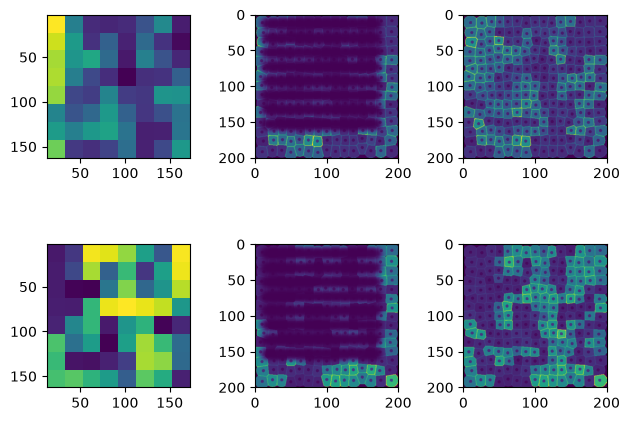

In [68]:

beam = GaussianBeam(sigma_x=5, sigma_y=5, I0=1e4)

scan = RasterScan.from_timing(x_start=12.5, y_start=12.5, n_pix=8, n_lines=8, velocity=200, t_sampling=0.1, pixel_y=20,)

print(f"x pitch: {scan.pixel_x}, y pitch: {scan.pixel_y}, beam fwhm: {beam.fwhm()}")
print(f"x linescan (um): {scan.pixel_x * scan.n_pix}, x linescan (um): {scan.pixel_y * scan.n_lines} ")


k = k_for_consumption(0.99, beam, scan)


img, rho = simulate_raster(rho_random, grid, beam, scan, k=k)


fig, axs = plt.subplots(2,3)

for i in range(2):
    axs[i,0].imshow(img[i,:,:], extent=scan_extent(scan)) 
    axs[i,1].imshow(rho[i,:,:], extent=grid.extent)
    axs[i,2].imshow(rho_random[i],  extent=grid.extent)

plt.tight_layout()

x pitch: 10.0, y pitch: 10, beam fwhm: (np.float64(11.774100225154747), np.float64(11.774100225154747))
x linescan (um): 170.0, x linescan (um): 170 


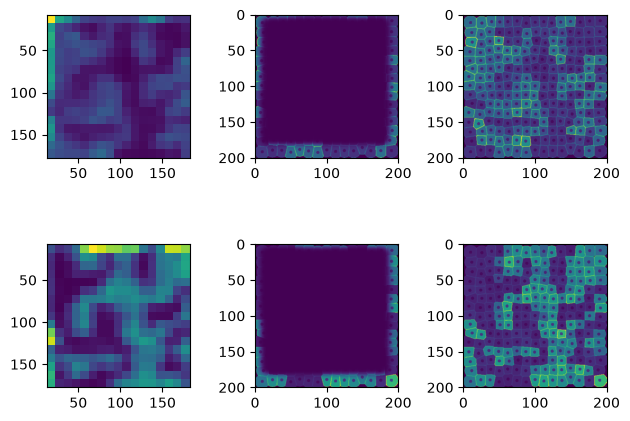

In [65]:

beam = GaussianBeam(sigma_x=5, sigma_y=5, I0=1e4)

scan = RasterScan.from_timing(x_start=12.5, y_start=12.5, n_pix=17, n_lines=17, velocity=100, t_sampling=0.1, pixel_y=10,)

print(f"x pitch: {scan.pixel_x}, y pitch: {scan.pixel_y}, beam fwhm: {beam.fwhm()}")
print(f"x linescan (um): {scan.pixel_x * scan.n_pix}, x linescan (um): {scan.pixel_y * scan.n_lines} ")


k = k_for_consumption(0.99, beam, scan)


img, rho = simulate_raster(rho_random, grid, beam, scan, k=k)


fig, axs = plt.subplots(2,3)

for i in range(2):
    axs[i,0].imshow(img[i,:,:], extent=scan_extent(scan)) 
    axs[i,1].imshow(rho[i,:,:], extent=grid.extent)
    axs[i,2].imshow(rho_random[i],  extent=grid.extent)

plt.tight_layout()

x pitch: 5.0, y pitch: 5, beam fwhm: (np.float64(11.774100225154747), np.float64(11.774100225154747))
x linescan (um): 175.0, x linescan (um): 175 


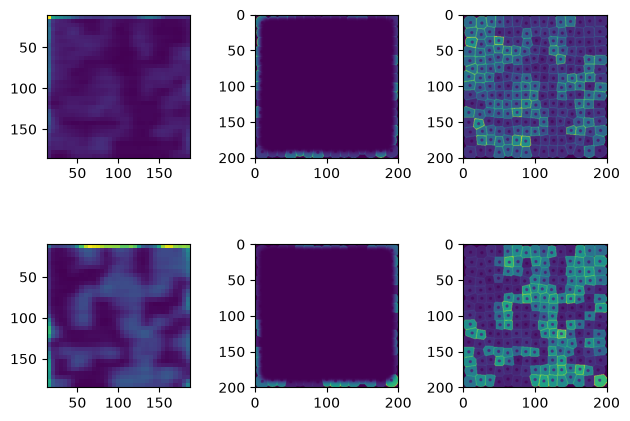

In [69]:

beam = GaussianBeam(sigma_x=5, sigma_y=5, I0=1e4)

scan = RasterScan.from_timing(x_start=12.5, y_start=12.5, n_pix=35, n_lines=35, velocity=50, t_sampling=0.1, pixel_y=5,)

print(f"x pitch: {scan.pixel_x}, y pitch: {scan.pixel_y}, beam fwhm: {beam.fwhm()}")
print(f"x linescan (um): {scan.pixel_x * scan.n_pix}, x linescan (um): {scan.pixel_y * scan.n_lines} ")


k = k_for_consumption(0.99, beam, scan)


img, rho = simulate_raster(rho_random, grid, beam, scan, k=k)


fig, axs = plt.subplots(2,3)

for i in range(2):
    axs[i,0].imshow(img[i,:,:], extent=scan_extent(scan)) 
    axs[i,1].imshow(rho[i,:,:], extent=grid.extent)
    axs[i,2].imshow(rho_random[i],  extent=grid.extent)

plt.tight_layout()

x pitch: 1.0, y pitch: 1, beam fwhm: (np.float64(4.709640090061899), np.float64(4.709640090061899))
x linescan (um): 175.0, x linescan (um): 175 


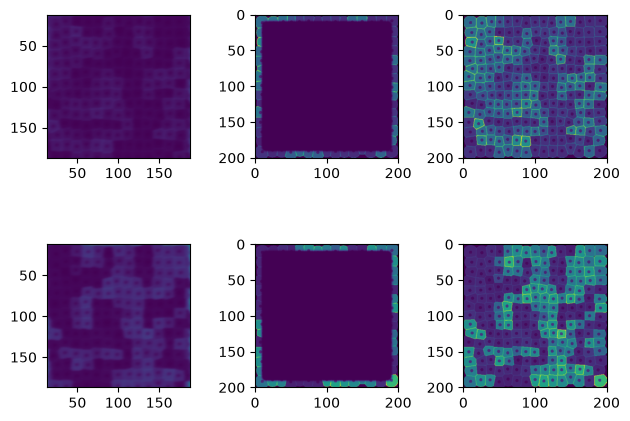

In [70]:

beam = GaussianBeam(sigma_x=2, sigma_y=2, I0=1e4)

scan = RasterScan.from_timing(x_start=12.5, y_start=12.5, n_pix=35 * 5, n_lines=35 * 5, velocity=10, t_sampling=0.1, pixel_y=1,)


print(f"x pitch: {scan.pixel_x}, y pitch: {scan.pixel_y}, beam fwhm: {beam.fwhm()}")
print(f"x linescan (um): {scan.pixel_x * scan.n_pix}, x linescan (um): {scan.pixel_y * scan.n_lines} ")


k = k_for_consumption(0.99, beam, scan)


img, rho = simulate_raster(rho_random, grid, beam, scan, k=k)



fig, axs = plt.subplots(2,3)

for i in range(2):
    axs[i,0].imshow(img[i,:,:], extent=scan_extent(scan)) 
    axs[i,1].imshow(rho[i,:,:], extent=grid.extent)
    axs[i,2].imshow(rho_random[i],  extent=grid.extent)

plt.tight_layout()

## Integrating mass spectrometer physics.

I'd suggest 